In [12]:
import polars as pl
from pathlib import Path
import polars.selectors as cs

In [5]:
recommendations_path = Path('/projectnb/vkolagrp/bellitti/clinicalnotes-databasing-validated/results/recommendations_tabulated.parquet')

recs = pl.read_parquet(recommendations_path)

tabular_path = Path('/projectnb/vkolagrp/bellitti/clinicalnotes-databasing-validated/results/NBSE_tabulated.parquet')

tabular = pl.read_parquet(tabular_path)

In [21]:
reports_with_recs = tabular.select(
    'VAC',
    'completed',
    'age',
    'sex',
    'education'
).join(recs,on='VAC')

In [30]:
rec_counts = reports_with_recs.select(cs.contains('recommended')).sum().to_pandas().transpose()

In [31]:
rec_counts

,0
neuropsychological_testing_recommended,131
amyloid_pet_recommended,499
fdg_pet_recommended,46
eeg_recommended,15
dat_scan_recommended,21
spect_recommended,1
sleep_study_recommended,81
lumbar_puncture_recommended,24


In [45]:
(rec_counts/len(reports_with_recs)*100).round(2)

,0
neuropsychological_testing_recommended,7.05
amyloid_pet_recommended,26.86
fdg_pet_recommended,2.48
eeg_recommended,0.81
dat_scan_recommended,1.13
spect_recommended,0.05
sleep_study_recommended,4.36
lumbar_puncture_recommended,1.29


In [23]:
df = reports_with_recs.select('completed','neuropsychological_testing_recommended').to_pandas()

In [24]:
df

,completed,neuropsychological_testing_recommended
0,2022-04-12,None
1,2019-06-24,None
2,2024-03-26,False
3,2023-02-14,False
4,2023-12-18,False
...,...,...
1853,2021-09-30,None
1854,2021-01-15,None
1855,2017-09-11,False
1856,2023-03-17,True


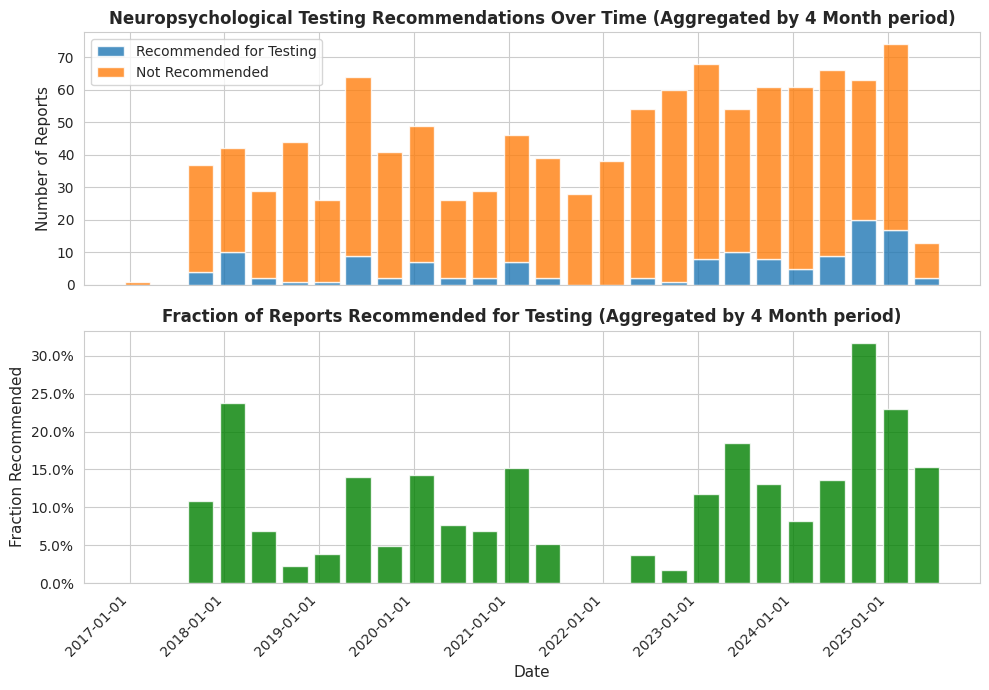


Summary Statistics:
Aggregation period: 4ME
Total reports: 1113
Total recommended: 131
Overall recommendation rate: 11.8%

Date range: 2017-01-31 00:00:00 to 2025-05-31 00:00:00
Number of periods: 26


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set seaborn whitegrid style
sns.set_style("whitegrid")

# Assuming you have a dataframe 'df' with columns:
# - 'completed': date column
# - 'neuropsychological_testing_recommended': boolean column

# Example data creation (replace this with your actual dataframe)
# df = pd.read_csv('your_data.csv')
# df['completed'] = pd.to_datetime(df['completed'])

# Ensure the date column is in datetime format
df['completed'] = pd.to_datetime(df['completed'])

# Sort by date
df = df.sort_values('completed')

# AGGREGATION PERIOD - Change this to your desired period
# Options: 'D' (day), 'W' (week), 'ME' (month end), '3ME' (3 months), 'QE' (quarter end), 'YE' (year end)
aggregation_period = '4ME'  # <-- Change this value as needed
aggregation_period_readable = '4 Month period'  # <-- Change this value as needed

# Group by the specified period and calculate counts
period_stats = df.groupby(pd.Grouper(key='completed', freq=aggregation_period)).agg({
    'neuropsychological_testing_recommended': ['sum', 'count']
}).reset_index()

period_stats.columns = ['date', 'recommended_count', 'total_count']

# Calculate fraction, handling division by zero
period_stats['recommended_fraction'] = period_stats.apply(
    lambda row: row['recommended_count'] / row['total_count'] if row['total_count'] > 0 else None,
    axis=1
)

# Remove rows with None values for plotting
plot_stats = period_stats.dropna(subset=['recommended_fraction']).copy()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Calculate bar width based on aggregation period
bar_width = (period_stats['date'].diff().median().days * 0.8) if len(period_stats) > 1 else 30

# Plot 1: Absolute numbers as stacked bar chart
ax1.bar(period_stats['date'], period_stats['recommended_count'], 
        width=bar_width, label='Recommended for Testing', alpha=0.8)
ax1.bar(period_stats['date'], period_stats['total_count'] - period_stats['recommended_count'], 
        bottom=period_stats['recommended_count'], width=bar_width, 
        label='Not Recommended', alpha=0.8)
ax1.set_ylabel('Number of Reports', fontsize=11)
ax1.set_title(f'Neuropsychological Testing Recommendations Over Time (Aggregated by {aggregation_period_readable})', 
              fontsize=12, fontweight='bold')
ax1.legend(loc='best')

# Plot 2: Fractions as bar chart
ax2.bar(plot_stats['date'], plot_stats['recommended_fraction'], 
        width=bar_width, color='green', alpha=0.8)
ax2.set_ylabel('Fraction Recommended', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_title(f'Fraction of Reports Recommended for Testing (Aggregated by {aggregation_period_readable})', 
              fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# Format x-axis dates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Optional: Print summary statistics
print("\nSummary Statistics:")
print(f"Aggregation period: {aggregation_period}")
print(f"Total reports: {period_stats['total_count'].sum()}")
print(f"Total recommended: {period_stats['recommended_count'].sum()}")
overall_rate = period_stats['recommended_count'].sum() / period_stats['total_count'].sum() if period_stats['total_count'].sum() > 0 else 0
print(f"Overall recommendation rate: {overall_rate:.1%}")
print(f"\nDate range: {period_stats['date'].min()} to {period_stats['date'].max()}")
print(f"Number of periods: {len(period_stats)}")

In [49]:
tabular.select(cs.contains('cerad'))

cerad_encoding_total,cerad_delayed_recall,cerad_corrected_recognition_total
i64,i64,i64
3,1,7
11,0,7
13,4,7
20,8,10
3,0,5
…,…,…
26,10,10
15,4,10
9,2,7
